In [1]:
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo  # Available in Python 3.9+
import pytz
import os
import pandas as pd
import numpy as np
import logging
import time
import requests
from math import sqrt
#from datetime import time

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)



In [2]:
symbol = "TQQQ"

csv3_filename = "TQQQ_5min_Since_2016_v2_removingincomplete_days_2025-05-08.csv"
final_df_read = pd.read_csv(csv3_filename, parse_dates=['timestamp'])
final_df_read['timestamp'] = pd.to_datetime(final_df_read['timestamp'], utc=True, errors='coerce')
# Convert 'timestamp' from UTC to 'US/Eastern'
final_df_read['timestamp'] = final_df_read['timestamp'].dt.tz_convert('US/Eastern')

In [3]:
print(final_df_read)

                       timestamp     open      high       low     close  \
0      2016-01-04 09:30:00-05:00  106.650  106.7300  105.5600  105.8304   
1      2016-01-04 09:35:00-05:00  105.782  106.6700  105.7820  106.3800   
2      2016-01-04 09:40:00-05:00  106.300  106.4153  105.1600  105.2500   
3      2016-01-04 09:45:00-05:00  105.225  105.7600  104.9000  105.4500   
4      2016-01-04 09:50:00-05:00  105.550  105.8200  105.4900  105.6200   
...                          ...      ...       ...       ...       ...   
181579 2025-05-07 15:35:00-04:00   55.850   56.4100   55.8300   56.3050   
181580 2025-05-07 15:40:00-04:00   56.290   58.2600   56.2000   57.6800   
181581 2025-05-07 15:45:00-04:00   57.670   58.0700   57.0101   57.0880   
181582 2025-05-07 15:50:00-04:00   57.080   57.2600   56.4450   56.9800   
181583 2025-05-07 15:55:00-04:00   56.990   57.6000   56.9200   57.4100   

         volume  trade_count        vwap        date  
0        387940         1399  106.391221  20

**Basic ORB strategy**

In [84]:
from datetime import timedelta
# Initialize Account Parameters
initial_account_value = 25000  # Total capital
risk_percent = 0.01    # 1% risk per trade

def compute_candle(sub_candles):
    open_price = sub_candles.iloc[0]['open']
    close_price = sub_candles.iloc[-1]['close']
    high_price = sub_candles['high'].max()
    low_price = sub_candles['low'].min()
    return open_price, high_price, low_price, close_price

def create_audit_df(audit_data):
    audit_df = pd.DataFrame(audit_data)

    # Reorder columns for clarity
    audit_df = audit_df[[ 
        'date', 'first_window_open', 'first_window_high', 'first_window_low', 'first_window_close',
        'position', 'entry_price', 'Risk', 'Profit_Target', 'percentage_return',
        'result_dollars_1share', 'result_in_R', 'firstTermSharesCalc', 'secondTermSharesCalc',
        'final_Shares', 'dollar_profit', 'stop_loss_hit', 'profit_target_hit', 'exit_time', 
        'exit_price', 'exit_condition', 'daily_result', 'account_value_end'
    ]]

    # Optional: Rename window columns to more descriptive names
    # audit_df = audit_df.rename(columns={
    #     'first_window_open': 'first_5min_open',
    #     'first_window_high': 'first_5min_high',
    #     'first_window_low': 'first_5min_low',
    #     'first_window_close': 'first_5min_close'
    # })

    return audit_df



    

def simple_orb(df, window_size, entry,leverage="Yes"):
    
    #SETUP
    #account
    account_value=initial_account_value

    # Ensure timestamp is in datetime format and localized to Eastern Time
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp')
    if df.index.tz is None:
        df = df.tz_localize('US/Eastern')
    else:
        df = df.tz_convert('US/Eastern')

    # Sort by timestamp
    df = df.sort_index()
    
    # Initialize list to collect audit data
    audit_data = []
    
    
    #STRATEGY
    # Extract date for grouping
    df['date'] = df.index.date
    
    #group by day
    grouped = df.groupby('date')
    for date, group in grouped:
        day_data=group
        
        #select n 5minute periods
        n=window_size//5
        first_candle=group.iloc[0:n, :]
        open_price, high_price, low_price, close_price=compute_candle(first_candle)
        

        # Calculate the movement in the opening range
        movement = abs(close_price - open_price)
        threshold = 0.0002 * open_price  # 0.02% of the open price
        # No Position Condition:
        #Do not take a position on days when the difference between the open and close of the opening window is not greater than 0.02% of the open price of the day.
        # Check if the movement exceeds the threshold
        if movement <= threshold:
            # Movement is too small; do not take a position on this day
            continue #This statement skips the rest of the loop for the current
            
        
        #generate long or sell signal
        signal=None
        if (close_price>open_price):
            signal="long"
        else:
            signal="short"
        
        #COMPUTE ENTRY STRATEGIES
        #buying time is right in the next candle
        entry_time = first_candle.index[-1] + timedelta(minutes=5)
            
        #entry price
        entry_price = day_data.loc[entry_time, 'open']
                          
        #obtain data for the rest of the day
        #HUGE DIFFERENCE
        remaining_data=day_data[day_data.index >= entry_time]
            
            
        #COMPUTE EXIT STRATEGIES
        exit=False

        #10R or EoD
            
        # For "long" strategy
        if signal == "long":
            stop_loss = low_price
            risk = entry_price - stop_loss
            target = entry_price + 10 * risk
            target=np.inf
                

            # Iterate through remaining data for "long" position
            for idx, candle in remaining_data.iterrows():
                high = candle['high']
                low = candle['low']
                close = candle['close']
                    
                stop_loss_hit_flag = 'No'
                profit_target_hit_flag = 'No'

                if low <= stop_loss:  # Stop loss hit
                    exit_price = stop_loss
                    stop_loss_hit_flag = 'Yes'
                    exit = True
                    exit_condition="Stop Loss"
                    break
                elif high >= target:  # Target hit
                    exit_price = target
                    profit_target_hit_flag = 'True'
                    exit = True
                    exit_condition="Profit Target"
                    break
                        
                # If no exit condition met
                if not exit:
                    exit_condition="EOD"
                    exit_price = remaining_data['close'].iloc[-1]  # Last close price
            
            #Compute profit after day loop
            exit_time=idx
            profit= (exit_price - entry_price)


        # For "short" strategy
        elif signal == "short":
            stop_loss = high_price
            risk = stop_loss - entry_price
            target = entry_price - 10 * risk
            target = -np.inf
            
               
            #if date== datetime(2016, 2, 26).date():
                #print(remaining_data)
                

            # Iterate through remaining data for "short" position
            for idx, candle in remaining_data.iterrows():
                high = candle['high']
                low = candle['low']
                close = candle['close']
                    
                stop_loss_hit_flag = 'No'
                profit_target_hit_flag = 'No'
                    
                if high >= stop_loss:  # Stop loss hit
                    exit_price = stop_loss
                    stop_loss_hit_flag = 'Yes'
                    exit = True
                    exit_condition="Stop Loss"
                    break
                elif low <= target:  # Target hit
                    exit_price = target
                    profit_target_hit_flag = 'Yes'
                    exit = True
                    exit_condition="Profit Target"
                    break

                # If no exit condition met
                if not exit:
                    exit_condition="EOD"
                    exit_price = remaining_data['close'].iloc[-1]  # Last close price
            
            #Compute profit after looping through day
            exit_time=idx
            profit =  (entry_price - exit_price)
        
        
        #RISK MANAGEMENT
        firstTermSharesCalc = (account_value * risk_percent) / risk
        
        
        # Determine secondTermSharesCalc based on leverage
        if leverage == 'Yes':
                secondTermSharesCalc = (account_value * 4) / entry_price
        else:  # leverage == 'No'
                secondTermSharesCalc = account_value / entry_price
        final_Shares = int(min(firstTermSharesCalc, secondTermSharesCalc))
        
        # Calculate Dollar Profit
        dollar_profit = final_Shares * profit
        
        # Determine daily result
        if profit > 0:
            daily_result = 'Win'
        else:
            daily_result = 'Loss'

        # Update account value
        account_value += dollar_profit
        
                
        #AUDIT
        audit_data.append({
            'date': date,
            'first_window_open': open_price,
            'first_window_high': high_price,
            'first_window_low': low_price,
            'first_window_close': close_price,
            'position': signal,
            'entry_price': entry_price,
            'Risk': round(risk, 2),
            'Profit_Target': round(10 * risk, 2),
            'percentage_return': round(profit*100/entry_price, 4),
            'result_dollars_1share': round(profit, 2),
            'result_in_R': round(profit/risk, 4),
            'firstTermSharesCalc': round(firstTermSharesCalc, 0),
            'secondTermSharesCalc': round(secondTermSharesCalc, 0),
            'final_Shares': final_Shares,
            'dollar_profit': round(dollar_profit, 2),
            'stop_loss_hit': stop_loss_hit_flag,
            'profit_target_hit': profit_target_hit_flag,
            'exit_time': idx,
            'exit_price': exit_price,
            'exit_condition': exit_condition,
            'daily_result': daily_result,
            'account_value_end': round(account_value, 2)
        })
        
    
    return create_audit_df(audit_data)
    

        
        
        
    
    
    
audit=simple_orb(final_df_read,5,"basic")

In [85]:
print(audit)

            date  first_window_open  first_window_high  first_window_low  \
0     2016-01-04            106.650           106.7300          105.5600   
1     2016-01-05            108.500           108.9300          107.8750   
2     2016-01-06            100.980           101.8300          100.8400   
3     2016-01-07             96.700            96.7900           96.0500   
4     2016-01-08             95.610            96.9600           95.3800   
...          ...                ...                ...               ...   
2256  2025-05-01             57.560            57.7400           57.0909   
2257  2025-05-02             58.640            58.9300           58.5000   
2258  2025-05-05             57.895            58.1399           57.7500   
2259  2025-05-06             56.060            56.4700           55.9000   
2260  2025-05-07             56.960            57.1599           56.6800   

      first_window_close position  entry_price  Risk  Profit_Target  \
0               

In [98]:
def above_threshold(close_price,open_price,threshold_percentage):
    # Calculate the movement in the opening range
    movement = abs(close_price - open_price)
    threshold =  (threshold_percentage/100) * open_price   # 0.02% of the open price

    #Take a position on days when the movement is high
    if movement > threshold:
        return True
    else:
        return False
    
def basic_entry(day_data,first_candle, open_price, high_price, low_price, close_price):
    
    #generate long or sell signal
    signal=None
    if (close_price>open_price):
        signal="long"
    elif(close_price<open_price):
        signal="short"
    else:
        #THE ABOVE THRESHOLD FUNCITON SHOULD IMPLEMENT THE CASE WHEN MOVEMENT IS 0
        print("ERROR")
        
    #buying time is right in the next candle
    entry_time = first_candle.index[-1] + timedelta(minutes=5)
            
    #entry price
    entry_price = day_data.loc[entry_time, 'open']
                          
    #obtain data for the rest of the day
    remaining_data=day_data[day_data.index >= entry_time]
                    
    return signal, entry_time, entry_price, remaining_data

#compute stop loss
def compute_stop_loss_risk(signal, high_price, low_price, entry_price):
    if signal == "long":
        stop_loss = low_price
        risk = entry_price - stop_loss

    elif signal == "short":
        stop_loss = high_price
        risk =  stop_loss - entry_price

    return stop_loss,risk

#compute if stop loss hit given daily candles
def stop_loss_hit(signal,stop_loss,candle):
    high = candle['high']
    low = candle['low']
    close = candle['close']
            
    exit_price=None
    if signal=="long":
        if low <= stop_loss:  # Stop loss hit
            exit_price = stop_loss
                    
    elif signal=="short":
        if high >= stop_loss:  # Stop loss hit
            exit_price = stop_loss
                    
    return exit_price

#compute target and risk lvels
def compute_target(profit_target_multiplier,signal,entry_price,risk):
    if profit_target_multiplier==None:
        profit_target_multiplier=np.inf
    
    if signal == "long":
        target = entry_price + profit_target_multiplier * risk
    elif signal == "short":
        target = entry_price - profit_target_multiplier * risk
    return target

#compute if hit daily
def profit_target_hit(signal, target,candle):
    high = candle['high']
    low = candle['low']
    close = candle['close']
    
    #when no profit target we just wait EoD or stop loss
    if target==None:
        return None
            
    exit_price=None
    if signal=="long":
        if high >= target:  # Target hit
            exit_price = target
                    
    elif signal=="short":
        if low <= target:  # Target hit
            exit_price = target
                    
    return exit_price
    
    
def generalized_orb(df, window_size, leverage, profit_target_multiplier, stop_loss, threshold, entry):
    # WINDOW_SIZE: [5,10,15 min]
    # LEVERAGE: None, 3x, 4x, 12x
    # PROFIT TARGET: [None, 5R, 10R]
    # STOP_LOSS: Low, ATR, Low + ATR
    # THRESHOLD: [None, 0.02%]
    # STOP_ENTRY: [basic,advanced]
    
    
    
    #SETUP
    #account
    account_value=initial_account_value

    # Ensure timestamp is in datetime format and localized to Eastern Time
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp')
    if df.index.tz is None:
        df = df.tz_localize('US/Eastern')
    else:
        df = df.tz_convert('US/Eastern')

    # Sort by timestamp
    df = df.sort_index()
    
    # Initialize list to collect audit data
    audit_data = []
    
    
    #STRATEGY
    # Extract date for grouping
    df['date'] = df.index.date
    
    #group by day
    grouped = df.groupby('date')
    for date, group in grouped:
        day_data=group
        
        #select n 5minute periods
        n=window_size//5
        first_candle=group.iloc[0:n, :]
        open_price, high_price, low_price, close_price=compute_candle(first_candle)
        

        #Check Threshold
        if not above_threshold(close_price,open_price,threshold):
            continue

    
        #COMPUTE ENTRY STRATEGIES
        if entry=="basic":
            signal, entry_time, entry_price, remaining_data = basic_entry(day_data, first_candle, open_price, high_price, low_price, close_price)


        #COMPUTE EXIT STRATEGIES              
        stop_loss_hit_flag = 'No'
        profit_target_hit_flag = 'No'        
        
        stop_loss,risk=compute_stop_loss_risk(signal, high_price, low_price, entry_price)
        target=compute_target(profit_target_multiplier,signal,entry_price,risk)
        
        #Loop through the day until exit or EOD
        exit=False
        stop_loss_hit_flag = 'No'
        profit_target_hit_flag = 'No'  
        for idx, candle in remaining_data.iterrows():
            
            #Exit Price: Stop-loss, Profit, or None (Keep waiting for end of the day)            
            exit_price=stop_loss_hit(signal, stop_loss, candle)
            if exit_price!=None:
                stop_loss_hit_flag = 'Yes'
                exit = True
                exit_condition="Stop Loss"
                exit_time=idx
                break
                
            exit_price=profit_target_hit(signal, target, candle)
            if exit_price!=None:
                profit_target_hit_flag = 'Yes'
                exit=True
                exit_condition="Profit Target"
                exit_time=idx
                break
                
                      
        # If no exit condition met we exit EOD
        if not exit:
            exit_condition="EOD"
            exit_price = remaining_data['close'].iloc[-1]  # Last close price
            exit_time=idx

                
        #Compute profit after day loop
        if signal=="long":
            profit= (exit_price - entry_price)
        elif signal=="short":
            profit =  (entry_price - exit_price)

               
        #CAREFUL WHENTRY PRICE = STOP LOSS, RISK EQUALS 0
        firstTermSharesCalc = (account_value * risk_percent) / risk     
        
        # Determine secondTermSharesCalc based on leverage
        if leverage == 'Yes':
                secondTermSharesCalc = (account_value * 4) / entry_price
        else:  # leverage == 'No'
                secondTermSharesCalc = account_value / entry_price
        final_Shares = int(min(firstTermSharesCalc, secondTermSharesCalc))
        
        # Calculate Dollar Profit
        dollar_profit = final_Shares * profit
        
        # Determine daily result
        if profit > 0:
            daily_result = 'Win'
        else:
            daily_result = 'Loss'

        # Update account value
        account_value += dollar_profit
        
                
        #AUDIT
        audit_data.append({
            'date': date,
            'first_window_open': open_price,
            'first_window_high': high_price,
            'first_window_low': low_price,
            'first_window_close': close_price,
            'position': signal,
            'entry_price': entry_price,
            'Risk': round(risk, 2),
            'Profit_Target': round(10 * risk, 2),
            'percentage_return': round(profit*100/entry_price, 4),
            'result_dollars_1share': round(profit, 2),
            'result_in_R': round(profit/risk, 4),
            'firstTermSharesCalc': round(firstTermSharesCalc, 0),
            'secondTermSharesCalc': round(secondTermSharesCalc, 0),
            'final_Shares': final_Shares,
            'dollar_profit': round(dollar_profit, 2),
            'stop_loss_hit': stop_loss_hit_flag,
            'profit_target_hit': profit_target_hit_flag,
            'exit_time': idx,
            'exit_price': exit_price,
            'exit_condition': exit_condition,
            'daily_result': daily_result,
            'account_value_end': round(account_value, 2)
        })
        
    
    return create_audit_df(audit_data)
    

        
        
window_size=5 #5,10,20
leverage="Yes"
profit_target_multiplier=10 #None, 5, 10
stop_loss=None
threshold=0.02
entry="basic"
    
    
audit=generalized_orb(final_df_read, window_size, leverage, profit_target_multiplier, stop_loss, threshold, entry)

In [99]:
print(audit)

            date  first_window_open  first_window_high  first_window_low  \
0     2016-01-04            106.650           106.7300          105.5600   
1     2016-01-05            108.500           108.9300          107.8750   
2     2016-01-06            100.980           101.8300          100.8400   
3     2016-01-07             96.700            96.7900           96.0500   
4     2016-01-08             95.610            96.9600           95.3800   
...          ...                ...                ...               ...   
2256  2025-05-01             57.560            57.7400           57.0909   
2257  2025-05-02             58.640            58.9300           58.5000   
2258  2025-05-05             57.895            58.1399           57.7500   
2259  2025-05-06             56.060            56.4700           55.9000   
2260  2025-05-07             56.960            57.1599           56.6800   

      first_window_close position  entry_price  Risk  Profit_Target  \
0               

In [102]:
from datetime import timedelta
# Initialize Account Parameters
initial_account_value = 25000  # Total capital
risk_percent = 0.01    # 1% risk per trade

   

def advanced_orb(df, window_size, entry,leverage="Yes"):
    
    #SETUP
    #account
    account_value=initial_account_value

    # Ensure timestamp is in datetime format and localized to Eastern Time
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp')
    if df.index.tz is None:
        df = df.tz_localize('US/Eastern')
    else:
        df = df.tz_convert('US/Eastern')

    # Sort by timestamp
    df = df.sort_index()
    
    # Initialize list to collect audit data
    audit_data = []
    
    
    #STRATEGY
    # Extract date for grouping
    df['date'] = df.index.date
    
    #group by day
    grouped = df.groupby('date')
    for date, group in grouped:
        day_data=group
        
        #select n 5minute periods
        n=window_size//5
        first_candle=group.iloc[0:n, :]
        open_price, high_price, low_price, close_price=compute_candle(first_candle)
        
        # Calculate the movement in the opening range
        movement = abs(close_price - open_price)
        threshold = 0.0002 * open_price  # 0.02% of the open price
        # No Position Condition:
        #Do not take a position on days when the difference between the open and close of the opening window is not greater than 0.02% of the open price of the day.
        # Check if the movement exceeds the threshold
        if movement <= threshold:
            # Movement is too small; do not take a position on this day
            continue #This statement skips the rest of the loop for the current
            
            
        #COMPUTE ENTRY STRATEGIES
        #generate long or sell signal
        signal=None
        if (close_price>open_price):
            signal="long"
            target_buy = high_price
        else:
            signal="short"
            target_buy = low_price
        
        #COMPUTE ENTRY STRATEGIES
        next_time = first_candle.index[-1] + timedelta(minutes=5)
        next_data=day_data[day_data.index >= next_time]
        
        #check if the buying condition is met:
        entry_time=None
        for idx, candle in next_data.iterrows():
            high = candle['high']
            low = candle['low']
            
            if signal=="long":
                if high >= target_buy:
                    #assume that the market wont reeach target or stopp loss within this 5min
                    entry_price=target_buy
                    entry_time = idx
                    
                    #obtain data for the rest of the day
                    remaining_data=next_data[next_data.index >= entry_time+ timedelta(minutes=5)]
                    break
                    
            if signal=="short":
                if low <= target_buy:
                    #assume that the market wont reeach target or stopp loss within this 5min
                    entry_price=target_buy
                    entry_time = idx
                    
                    #obtain data for the rest of the day
                    remaining_data=next_data[next_data.index >= entry_time+ timedelta(minutes=5)]
                    
                    if date== datetime(2022, 3, 23).date():
                        print("YESS3")
                        print(entry_time)
                        print(remaining_data)
                    break
                    
        #if day passes and no entry, skip day
        if entry_time==None:
            continue
            
        #COMPUTE EXIT STRATEGIES
        exit=False

        #10R or EoD
        # For "long" strategy
        if signal == "long":
            stop_loss = low_price
            risk = entry_price - stop_loss
            target = entry_price + 10 * risk
                

            # Iterate through remaining data for "long" position
            for idx, candle in remaining_data.iterrows():
                high = candle['high']
                low = candle['low']
                close = candle['close']
                    
                stop_loss_hit_flag = 'No'
                profit_target_hit_flag = 'No'

                if low <= stop_loss:  # Stop loss hit
                    exit_price = stop_loss
                    stop_loss_hit_flag = 'Yes'
                    exit = True
                    exit_condition="Stop Loss"
                    break
                elif high >= target:  # Target hit
                    exit_price = target
                    profit_target_hit_flag = 'True'
                    exit = True
                    exit_condition="Profit Target"
                    break
                        
                # If no exit condition met
                if not exit:
                    exit_condition="EOD"
                    exit_price = remaining_data['close'].iloc[-1]  # Last close price
            
            #Compute profit after day loop
            exit_time=idx
            profit= (exit_price - entry_price)


        # For "short" strategy
        elif signal == "short":
            stop_loss = high_price
            risk = stop_loss - entry_price
            target = entry_price - 10 * risk          
                

            # Iterate through remaining data for "short" position
            if date== datetime(2022, 3, 23).date():
                print("YESS3")
                print(entry_time)
                print(remaining_data)
        
            for idx, candle in remaining_data.iterrows():
                high = candle['high']
                low = candle['low']
                close = candle['close']
                    
                stop_loss_hit_flag = 'No'
                profit_target_hit_flag = 'No'
                    
                if high >= stop_loss:  # Stop loss hit
                    exit_price = stop_loss
                    stop_loss_hit_flag = 'Yes'
                    exit = True
                    exit_condition="Stop Loss"
                    break
                elif low <= target:  # Target hit
                    exit_price = target
                    profit_target_hit_flag = 'Yes'
                    exit = True
                    exit_condition="Profit Target"
                    break

                # If no exit condition met
                if not exit:
                    exit_condition="EOD"
                    exit_price = remaining_data['close'].iloc[-1]  # Last close price
            
            #Compute profit after looping through day
            exit_time=idx
            profit =  (entry_price - exit_price)
            if date== datetime(2022, 3, 23).date():
                print("YESS3")
                print(exit_time)
                print(profit)
        
        
        #RISK MANAGEMENT
        firstTermSharesCalc = (account_value * risk_percent) / risk
        
        
        # Determine secondTermSharesCalc based on leverage
        if leverage == 'Yes':
                secondTermSharesCalc = (account_value * 4) / entry_price
        else:  # leverage == 'No'
                secondTermSharesCalc = account_value / entry_price
        final_Shares = int(min(firstTermSharesCalc, secondTermSharesCalc))
        
        # Calculate Dollar Profit
        dollar_profit = final_Shares * profit
        
        # Determine daily result
        if profit > 0:
            daily_result = 'Win'
        else:
            daily_result = 'Loss'

        # Update account value
        account_value += dollar_profit
        
                
        #AUDIT
        audit_data.append({
            'date': date,
            'first_window_open': open_price,
            'first_window_high': high_price,
            'first_window_low': low_price,
            'first_window_close': close_price,
            'position': signal,
            'entry_price': entry_price,
            'Risk': round(risk, 2),
            'Profit_Target': round(10 * risk, 2),
            'percentage_return': round(profit*100/entry_price, 4),
            'result_dollars_1share': round(profit, 2),
            'result_in_R': round(profit/risk, 4),
            'firstTermSharesCalc': round(firstTermSharesCalc, 0),
            'secondTermSharesCalc': round(secondTermSharesCalc, 0),
            'final_Shares': final_Shares,
            'dollar_profit': round(dollar_profit, 2),
            'stop_loss_hit': stop_loss_hit_flag,
            'stop_loss_hit_time': idx,
            'profit_target_hit': profit_target_hit_flag,
            'profit_target_hit_time': idx,
            'exit_time': idx,
            'exit_price': exit_price,
            'exit_condition': exit_condition,
            'daily_result': daily_result,
            'account_value_end': round(account_value, 2)
        })
        
    
    return create_audit_df(audit_data)
    

        
        
        
    
    
    
audit=advanced_orb(final_df_read,5,"basic")

YESS3
2022-03-23 15:55:00-04:00
Empty DataFrame
Columns: [open, high, low, close, volume, trade_count, vwap, date]
Index: []
YESS3
2022-03-23 15:55:00-04:00
Empty DataFrame
Columns: [open, high, low, close, volume, trade_count, vwap, date]
Index: []
YESS3
2022-03-23 15:55:00-04:00
-2.3100000000000023


In [7]:
print(audit)

            date  first_window_open  first_window_high  first_window_low  \
0     2016-01-04            106.650           106.7300          105.5600   
1     2016-01-05            108.500           108.9300          107.8750   
2     2016-01-06            100.980           101.8300          100.8400   
3     2016-01-07             96.700            96.7900           96.0500   
4     2016-01-08             95.610            96.9600           95.3800   
...          ...                ...                ...               ...   
2114  2025-05-01             57.560            57.7400           57.0909   
2115  2025-05-02             58.640            58.9300           58.5000   
2116  2025-05-05             57.895            58.1399           57.7500   
2117  2025-05-06             56.060            56.4700           55.9000   
2118  2025-05-07             56.960            57.1599           56.6800   

      first_window_close position  entry_price  Risk  Profit_Target  \
0               

**ATR**

In [67]:
# Initialize Account Parameters
initial_account_value = 25000  # Total capital
risk_percent = 0.01    # 1% risk per trade

#compute daily candle
def compute_candle(sub_candles):
    open_price = sub_candles.iloc[0]['open']
    close_price = sub_candles.iloc[-1]['close']
    high_price = sub_candles['high'].max()
    low_price = sub_candles['low'].min()
    return open_price, high_price, low_price, close_price

#copmute tr from daily candle
def compute_tr(high, low, prev_close):
    """
    Compute the True Range (TR) for one day.

    Parameters:
        high (float): High price of the current day.
        low (float): Low price of the current day.
        prev_close (float): Close price of the previous day.

    Returns:
        float: The True Range.
    """
    tr = max(
        abs(high - low),
        abs(high - prev_close),
        abs(low - prev_close)
    )
    return tr

atr_percent=0.05

def compute_atr(atr_df, date, period=14):
    """
    Function to compute the ATR (14-period) using Wilder's smoothed method, 
    given the TR values up to a specific date. ATR is calculated by considering 
    the TR column in the DataFrame.

    :param atr_df: A pandas DataFrame containing the 'tr' and 'atr' columns, indexed by date.
    :param date: The date for which to compute the ATR.
    :param period: The period over which to calculate the ATR (default is 14).
    :return: The ATR value for the specified date.
    """
    # Ensure we have enough data (at least 'period' TR values)
    if len(atr_df[:date]) < period:
        return None  # Return None if not enough data for ATR calculation
    
    # Compute initial ATR for the first 'period' days (a simple average of TR)
    if len(atr_df[:date]) == period:
        atr_value = atr_df['tr'][:date].mean()  # First ATR is just the average of the first 'period' TR values
    else:
        # Use Wilder's smoothing formula to compute the ATR from previous ATR value
        previous_atr = atr_df['atr'].iloc[-2]
        tr_value = atr_df.loc[date, 'tr']
        atr_value = (previous_atr * (period - 1) + tr_value) / period

    return atr_value



def simple_orb_ATR(df, window_size, entry,leverage="Yes"):
    
    #SETUP
    #account
    account_value=initial_account_value

    # Ensure timestamp is in datetime format and localized to Eastern Time
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp')
    if df.index.tz is None:
        df = df.tz_localize('US/Eastern')
    else:
        df = df.tz_convert('US/Eastern')

    # Sort by timestamp
    df = df.sort_index()
    
    # Initialize list to collect audit data
    audit_data = []
    
    
    #STRATEGY
    # Extract date for grouping
    df['date'] = df.index.date
    
    #group by day
    grouped = df.groupby('date')
    
    previous_day_close=None #FOR ATR
    atr_df = pd.DataFrame(columns=['tr', 'atr'])
    atr_df.index.name = 'date'
    
    for date, group in grouped:
        day_data=group
        
        #select n 5minute periods
        n=window_size//5
        first_candle=group.iloc[0:n, :]
        open_price, high_price, low_price, close_price=compute_candle(first_candle)       
     
        # Calculate the movement in the opening range
        movement = abs(close_price - open_price)
        threshold = 0.0002 * open_price  # 0.02% of the open price
        # No Position Condition:
        #Do not take a position on days when the difference between the open and close of the opening window is not greater than 0.02% of the open price of the day.
        # Check if the movement exceeds the threshold
        if movement <= threshold:
            # Movement is too small; do not take a position on this day
            continue #This statement skips the rest of the loop for the current
     
        
        #generate long or sell signal
        signal=None
        if (close_price>open_price):
            signal="long"
        else:
            signal="short"
        
        #COMPUTE ENTRY STRATEGIES
        #buying time is right in the next candle
        entry_time = first_candle.index[-1] + timedelta(minutes=5)
            
        #entry price
        entry_price = day_data.loc[entry_time, 'open']
                          
        #obtain data for the rest of the day
        remaining_data=day_data[day_data.index >= entry_time]
            
            
        #COMPUTE EXIT STRATEGIES; 10R or EoD or loss  
        exit=False
        
        #Compute daily TR
        open_day_price, high_day_price, low_day_price, close_day_price = compute_candle(day_data)
        #if date == datetime(2025, 5, 7).date() or date == datetime(2025, 5, 6).date():
            #print(date)
            #print("o,h,l,c",open_day_price, high_day_price, low_day_price, close_day_price)
        
        #its the first day, skip because TR needs previous dat
        if previous_day_close==None: 
            previous_day_close = close_day_price
            continue
                   
        #compute tr and update prvious close variable (not used anymore after this line) 
        tr=compute_tr(high_day_price,low_day_price, previous_day_close)
        atr_df.loc[date, 'tr'] = tr
        previous_day_close = close_day_price
        
        #compute ATR
        current_atr= compute_atr(atr_df,date,period=14)
        atr_df.loc[date, 'atr'] = current_atr
        if (current_atr==None):
            #less than 14 days, skip dat
            continue
        
        #if date == datetime(2025, 5, 7).date() or date == datetime(2025, 5, 6).date():
            #print(tr, current_atr)
        
        
        # For "long" strategy
        if signal == "long":
            stop_loss = entry_price - atr_percent*current_atr
            risk = entry_price - stop_loss
            target = entry_price + 10 * risk
                

            # Iterate through remaining data for "long" position
            for idx, candle in remaining_data.iterrows():
                high = candle['high']
                low = candle['low']
                close = candle['close']
                    
                stop_loss_hit_flag = 'No'
                profit_target_hit_flag = 'No'

                if low <= stop_loss:  # Stop loss hit
                    exit_price = stop_loss
                    stop_loss_hit_flag = 'Yes'
                    exit = True
                    exit_condition="Stop Loss"
                    break
                elif high >= target:  # Target hit
                    exit_price = target
                    profit_target_hit_flag = 'True'
                    exit = True
                    exit_condition="Profit Target"
                    break
                        
                # If no exit condition met
                if not exit:
                    exit_condition="EOD"
                    exit_price = remaining_data['close'].iloc[-1]  # Last close price
            
            #Compute profit after day loop
            exit_time=idx
            profit= (exit_price - entry_price)


        # For "short" strategy
        elif signal == "short":
            stop_loss = entry_price + atr_percent*current_atr
            risk = stop_loss - entry_price
            target = entry_price - 10 * risk
            
               
            #if date== datetime(2016, 2, 26).date():
                #print(remaining_data)
                

            # Iterate through remaining data for "short" position
            for idx, candle in remaining_data.iterrows():
                high = candle['high']
                low = candle['low']
                close = candle['close']
                    
                stop_loss_hit_flag = 'No'
                profit_target_hit_flag = 'No'
                    
                if high >= stop_loss:  # Stop loss hit
                    exit_price = stop_loss
                    stop_loss_hit_flag = 'Yes'
                    exit = True
                    exit_condition="Stop Loss"
                    break
                elif low <= target:  # Target hit
                    exit_price = target
                    profit_target_hit_flag = 'Yes'
                    exit = True
                    exit_condition="Profit Target"
                    break

                # If no exit condition met
                if not exit:
                    exit_condition="EOD"
                    exit_price = remaining_data['close'].iloc[-1]  # Last close price
            
            #Compute profit after looping through day
            exit_time=idx
            profit =  (entry_price - exit_price)
        
        
        #RISK MANAGEMENT
        firstTermSharesCalc = (account_value * risk_percent) / risk
        
        
        # Determine secondTermSharesCalc based on leverage
        if leverage == 'Yes':
                secondTermSharesCalc = (account_value * 4) / entry_price
        else:  # leverage == 'No'
                secondTermSharesCalc = account_value / entry_price

        final_Shares = int(min(firstTermSharesCalc, secondTermSharesCalc))
        
        # Calculate Dollar Profit
        dollar_profit = final_Shares * profit
        
        # Determine daily result
        if profit > 0:
            daily_result = 'Win'
        else:
            daily_result = 'Loss'

        # Update account value
        account_value += dollar_profit
        
                
        #AUDIT
        audit_data.append({
            'date': date,
            'first_window_open': open_price,
            'first_window_high': high_price,
            'first_window_low': low_price,
            'first_window_close': close_price,
            'position': signal,
            'entry_price': entry_price,
            'Risk': round(risk, 2),
            'Profit_Target': round(10 * risk, 2),
            'percentage_return': round(profit*100/entry_price, 4),
            'result_dollars_1share': round(profit, 2),
            'result_in_R': round(profit/risk, 4),
            'firstTermSharesCalc': round(firstTermSharesCalc, 0),
            'secondTermSharesCalc': round(secondTermSharesCalc, 0),
            'final_Shares': final_Shares,
            'dollar_profit': round(dollar_profit, 2),
            'stop_loss_hit': stop_loss_hit_flag,
            'stop_loss_hit_time': idx,
            'profit_target_hit': profit_target_hit_flag,
            'profit_target_hit_time': idx,
            'exit_time': idx,
            'exit_price': exit_price,
            'exit_condition': exit_condition,
            'daily_result': daily_result,
            'account_value_end': round(account_value, 2)
        })
        
    
    return create_audit_df(audit_data)
    

        
        
        
    
    
    
audit=simple_orb_ATR(final_df_read,5,"basic")

In [68]:
print(audit)

            date  first_window_open  first_window_high  first_window_low  \
0     2016-01-25             88.730            89.0200           88.4100   
1     2016-01-26             86.600            86.8600           85.9540   
2     2016-01-28             85.190            85.4000           84.7200   
3     2016-01-29             84.770            85.0600           84.5501   
4     2016-02-01             88.690            88.7900           88.1800   
...          ...                ...                ...               ...   
2242  2025-05-01             57.560            57.7400           57.0909   
2243  2025-05-02             58.640            58.9300           58.5000   
2244  2025-05-05             57.895            58.1399           57.7500   
2245  2025-05-06             56.060            56.4700           55.9000   
2246  2025-05-07             56.960            57.1599           56.6800   

      first_window_close position  entry_price  Risk  Profit_Target  \
0               

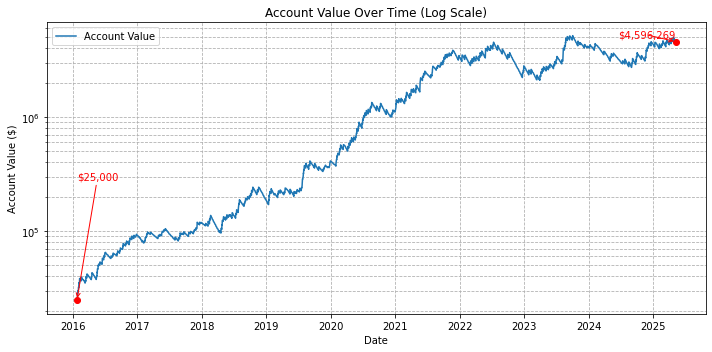

In [70]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure date is datetime and sort
audit['date'] = pd.to_datetime(audit['date'], errors='coerce')
audit = audit.sort_values('date')

# Extract data
dates = audit['date'].to_numpy()
values = audit['account_value_end'].to_numpy()

# Initial and final values
initial_date = dates[0]
initial_value = values[0]
final_date = dates[-1]
final_value = values[-1]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(dates, values, label='Account Value')

# Initial point (manual label)
plt.scatter(initial_date, initial_value, color='red', zorder=5)
plt.annotate(
    '$25,000',
    xy=(initial_date, initial_value),
    xytext=(initial_date, initial_value + 0.05 * values.max()),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red'
)

# Final point (full red, moved upward)
plt.scatter(final_date, final_value, color='red', zorder=5)
plt.annotate(
    '$4,596,269',  # Manually set final label
    xy=(final_date, final_value),
    xytext=(final_date, final_value + 0.07 * values.max()),  # moved higher
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red',
    horizontalalignment='right'
)

plt.xlabel('Date')
plt.ylabel('Account Value ($)')
plt.title('Account Value Over Time (Log Scale)')
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.grid(True, which="both", ls="--")
plt.legend()
plt.tight_layout()
plt.show()




In [71]:
import pandas as pd
import numpy as np

# Ensure correct format and sort on a copy of audit DataFrame
audit_copy = audit.copy()
audit_copy['date'] = pd.to_datetime(audit_copy['date'], errors='coerce')
audit_copy = audit_copy.sort_values('date')
audit_copy = audit_copy.set_index('date')

# Get the account values from the copy
values = audit_copy['account_value_end']

# Calculate running max (peak)
running_max = values.cummax()

# Drawdown from peak
drawdown = values / running_max - 1

# Max consecutive loss (max drawdown)
max_drawdown = drawdown.min()

# Convert to percentage
print(f"Max consecutive loss: {max_drawdown:.2%}")



Max consecutive loss: -53.64%


In [72]:
import pandas as pd

# Calculate daily changes (or returns)
daily_change = audit['account_value_end'].diff()

# Create a boolean Series: True if it's a loss, False otherwise
is_loss = daily_change < 0

# Count consecutive losses
max_streak = 0
current_streak = 0

for loss in is_loss:
    if loss:
        current_streak += 1
        max_streak = max(max_streak, current_streak)
    else:
        current_streak = 0

print(f"Max number of consecutive loss days: {max_streak}")


Max number of consecutive loss days: 50
